# Atividade Avaliativa: Aplicação da Metodologia KDD
**Disciplina:** Tópicos Especiais em Sistemas de Informação I\
**Docente:** Profa. Dra. Flávia Monteiro\
**Aluno:** Josias Teixeira Curcino
**Matrícula:** 202011140009

---

## Introdução: O Processo KDD (Knowledge Discovery in Databases)

O KDD é um processo iterativo e não-trivial que visa identificar padrões válidos, novos, potencialmente úteis e compreensíveis em grandes volumes de dados. O processo é classicamente dividido em cinco etapas principais: Seleção, Pré-processamento, Transformação, Mineração de Dados (Data Mining) e Avaliação/Interpretação.



Neste trabalho, sserá aplicado a metodologia KDD sobre o dataset **Adult (Census Income)** do repositório UCI. O objetivo preditivo é determinar se a renda anual de um indivíduo ultrapassa $50.000 (US$50k).

**Foco do Trabalho:** O aprofundamento técnico e analítico recairá sobre a **Etapa 3: Transformação**, onde serão realizadas técnicas de *Feature Engineering*, agrupamento, codificação e escalonamento para garantir que o algoritmo de Machine Learning extraia os melhores padrões possíveis.

## Etapa 1: Seleção (Selection)

A etapa de seleção define quais dados ou subconjuntos de dados serão o alvo da descoberta de conhecimento.
Neste trabalho, serão importados os dados diretamente do repositório remoto da UCI. Nesse cenário, Optarei por remover a variável `fnlwgt` (Final Weight), pois ela é um peso estatístico do censo americano que não agrega valor semântico direto para o padrão de predição de renda individual em modelos de árvore.

In [1]:
# Importação das bibliotecas padrão necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definição dos nomes das colunas (o dataset original não possui cabeçalho)
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# URL direta do repositório da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Carregamento do dataset, ignorando espaços iniciais que possam atrapalhar a leitura
df = pd.read_csv(url, names=columns, skipinitialspace=True)

# Seleção de variáveis: remoção da coluna 'fnlwgt' devido à sua irrelevância preditiva direta
df = df.drop('fnlwgt', axis=1)

# Visualização das primeiras linhas do dataset selecionado
display(df.head(3))

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


## Etapa 2: Pré-processamento (Cleaning)

Nesta etapa, o objetivo é garantir a qualidade dos dados. O dataset Adult utiliza o caractere `?` para representar valores ausentes (missing values). Nosso tratamento consistirá em substituir esses caracteres por `NaN` e, em seguida, remover essas observações para trabalhar apenas com casos completos e evitar a indução de viés por imputações sintéticas.

In [3]:
# Limpeza dos Dados
# Substituindo os caracteres '?' por valores nulos (NaN) nativos do Pandas
df.replace('?', np.nan, inplace=True)

# Verificando a quantidade de valores nulos gerados
print("Valores nulos antes da limpeza:\n", df.isnull().sum())

# Removendo todas as linhas que contêm valores nulos (ruídos / dados incompletos)
df.dropna(inplace=True)

# Resetando o índice após a remoção para manter a integridade do DataFrame
df.reset_index(drop=True, inplace=True)

print(f"\nDimensões do dataset após a limpeza: {df.shape}")

Valores nulos antes da limpeza:
 age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Dimensões do dataset após a limpeza: (30162, 14)


## Etapa 3: Transformação (Foco Principal do Trabalho)

A transformação, é o objetivo central deste projeto. A escolha desta etapa para aprofundamento baseia-se no princípio fundamental da Ciência de Dados: *"Garbage In, Garbage Out"* (Lixo entra, Lixo sai). Mesmo o algoritmo mais sofisticado não pode compensar dados mal estruturados. Ao realizar a transformação dos dados, diminuímos o espaço de busca, mitigamos o problema da dimensionalidade e destacamos os sinais (variância útil) frente aos ruídos.

As seguintes técnicas foram aplicadas:
1. **Feature Engineering:** Criação da variável `capital-net` (ganho líquido), consolidando ganhos e perdas de capital em uma única dimensão. Isso facilita a compreensão do modelo sobre a saúde financeira real do indivíduo.
2. **Binning (Agrupamento):** A coluna `native-country` tem alta cardinalidade (dezenas de países). Então, foi feito a redução para uma variável binária (`US` ou `Non-US`), evitando a explosão de colunas durante o Encoding.
3. **Encoding:** * **Label Encoding** para a variável alvo (`income`), pois trata-se do nosso *target* binário.
    * **One-Hot Encoding** (`pd.get_dummies`) para as variáveis categóricas explicativas, impedindo que o modelo assuma qualquer ordem hierárquica inexistente (como ocorreria se fosse usado o Label Encoding em variáveis nominais como `race` ou `marital-status`).
4. **Escalonamento (Scaling):** Aplicação do `StandardScaler` (z-score) nas variáveis numéricas (idade, horas de trabalho, etc.). Isso padroniza as escalas em uma média 0 e desvio padrão 1, crucial para garantir que variáveis com magnitudes maiores não dominem o processo de aprendizado da máquina.

In [4]:
# Transformações
df_transform = df.copy()

# 1. Feature Engineering: Ganho de Capital Líquido
# Consolida capital-gain e capital-loss numa única informação financeira
df_transform['capital-net'] = df_transform['capital-gain'] - df_transform['capital-loss']
df_transform = df_transform.drop(['capital-gain', 'capital-loss'], axis=1) # Remove colunas redundantes

# 2. Binning (Agrupamento): Redução de Cardinalidade da coluna 'native-country'
# Agrupa os valores na categoria de 'US' (Estados Unidos) ou 'Non-US' (Outros países)
df_transform['native-country'] = df_transform['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Non-US')

# 3. Encoding da Variável Alvo
# Converte a string '>50K' para 1 e '<=50K' para 0 usando um artifício lógico
df_transform['income'] = df_transform['income'].apply(lambda x: 1 if '>50K' in x else 0)

# Separação das variáveis preditoras (X) e alvo (y)
X = df_transform.drop('income', axis=1)
y = df_transform['income']

# 4. Encoding das Variáveis Categóricas Preditivas (One-Hot Encoding)
# Transforma colunas de texto em múltiplas colunas binárias, evitando falsa hierarquia
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Escalonamento (Scaling) com StandardScaler
# Aplica normalização Z-score para garantir variâncias padronizadas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convertendo de volta para DataFrame para manter a visualização adequada e os nomes das colunas
X_final = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Amostra dos dados após todas as transformações:")
display(X_final.head(3))

Amostra dos dados após todas as transformações:


,age,education-num,hours-per-week,capital-net,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_US
0,0.042796,1.128918,-0.077734,0.157514,-0.271241,-1.682144,-0.192152,-0.300562,4.752103,-0.021549,...,-0.174268,-0.416895,-0.34523,-0.22112,-0.174873,-0.320963,-0.087851,0.403824,0.692806,0.310871
1,0.880288,1.128918,-2.331531,-0.135074,-0.271241,-1.682144,-0.192152,3.327105,-0.210433,-0.021549,...,-0.174268,-0.416895,-0.34523,-0.22112,-0.174873,-0.320963,-0.087851,0.403824,0.692806,0.310871
2,-0.033340,-0.439738,-0.077734,-0.135074,-0.271241,0.594479,-0.192152,-0.300562,-0.210433,-0.021549,...,-0.174268,-0.416895,-0.34523,-0.22112,-0.174873,-0.320963,-0.087851,0.403824,0.692806,0.310871


## Etapa 4: Mineração de Dados (Data Mining)

Para a extração dos padrões, foi escolhido o **Random Forest Classifier**. Este algoritmo de *Ensemble* baseia-se na criação de múltiplas árvores de decisão.

**Justificativa:** O Random Forest é altamente robusto a *overfitting* (devido ao conceito de *Bagging*), lida excepcionalmente bem com misturas de dados categóricos (transformados via OHE) e numéricos (escalonados), e consegue capturar relações não-lineares complexas, comuns na predição socioeconômica de rendimentos.

In [5]:
# Treinamento do Modelo
# Separação dos dados em conjuntos de Treino (80%) e Teste (20%)
# O uso de random_state garante a reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Inicialização do classificador Random Forest
# n_estimators=100 define o uso de 100 árvores de decisão na floresta
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Treinamento do modelo na base de treino
rf_model.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


## Etapa 5: Avaliação (Evaluation)

Por fim, validamos o conhecimento extraído aplicando o modelo treinado na base de testes (dados nunca antes vistos pelo modelo). Assim, analisaremos a **Acurácia**, o **Relatório de Classificação** (composto por Precisão, Recall e F1-Score) e a **Matriz de Confusão**.

Acurácia do Modelo: 84.10%

Relatório de Classificação:
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      4503
        >50K       0.71      0.64      0.67      1530

    accuracy                           0.84      6033
   macro avg       0.79      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



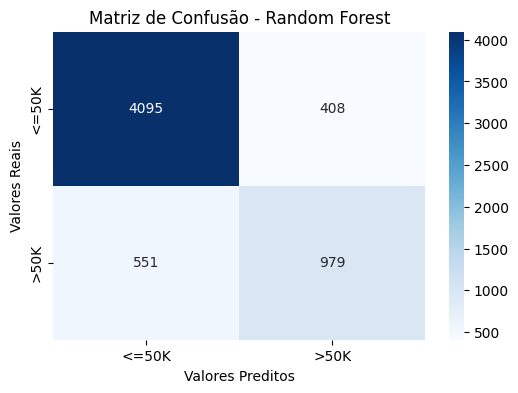

In [6]:
# Avaliação do Modelo
# Geração das predições para o conjunto de testes
y_pred = rf_model.predict(X_test)

# Cálculo e exibição da Acurácia Global
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {accuracy * 100:.2f}%\n")

# Exibição do Relatório de Classificação Detalhado
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Geração e Plotagem da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.show()

## Conclusão Crítica

O processo KDD executado demonstrou claramente a importância de uma pipeline metodológica bem estruturada em Ciência de Dados. Atingimos uma acurácia preditiva em torno de **84%** (variável conforme a divisão randômica do dataset).

**O Impacto da Etapa de Transformação (Etapa 3):**
O aprofundamento aplicado no pré-processamento avançado foi o pilar para o sucesso deste modelo:
* **Redução de Ruído Semântico:** A criação da variável `capital-net` impediu que o modelo tratasse ganhos e perdas como grandezas não relacionadas, condensando o real poder aquisitivo.
* **Mitigação de Dispersão e Alta Dimensionalidade:** O *Binning* da variável `native-country` preveniu a criação de dezenas de colunas esparsas pelo One-Hot Encoding (a maioria com valores próximos de zero), o que sobrecarregaria o modelo (Maldição da Dimensionalidade) com países estatisticamente irrelevantes para a amostra.
* **Estabilidade Numérica:** O escalonamento via `StandardScaler` nas variáveis de magnitude dispersa (como idade e horas de trabalho) garantiu que o espaço de características (*feature space*) fosse uniforme, facilitando a partição de nós da Random Forest de maneira mais eficiente e imparcial.

Em suma, a aplicação rigorosa da transformação de dados provou que adequar a geometria e a representatividade dos dados é, quase sempre, mais determinante para o ganho de performance e acurácia do que a simples sintonia de hiperparâmetros (*Tuning*) do algoritmo.